Assignment 3

In [10]:
options(warn = -1)

In [11]:
Sys.setenv(TZ = "UTC")

In [12]:
library(fpp3)
get_my_data <- function(student_id) {
  set.seed(student_id)
  all_data <- readr::read_rds("https://bit.ly/monashretaildata")
  while(TRUE) {
    retail <- filter(all_data, `Series ID` == sample(`Series ID`, 1))
    if(!any(is.na(fill_gaps(retail)$Turnover))) return(retail)
  }
}

retail <- get_my_data(2211769)

Use a training set up to and including 2018.

Plot variable not specified, automatically selected `.vars = Turnover`


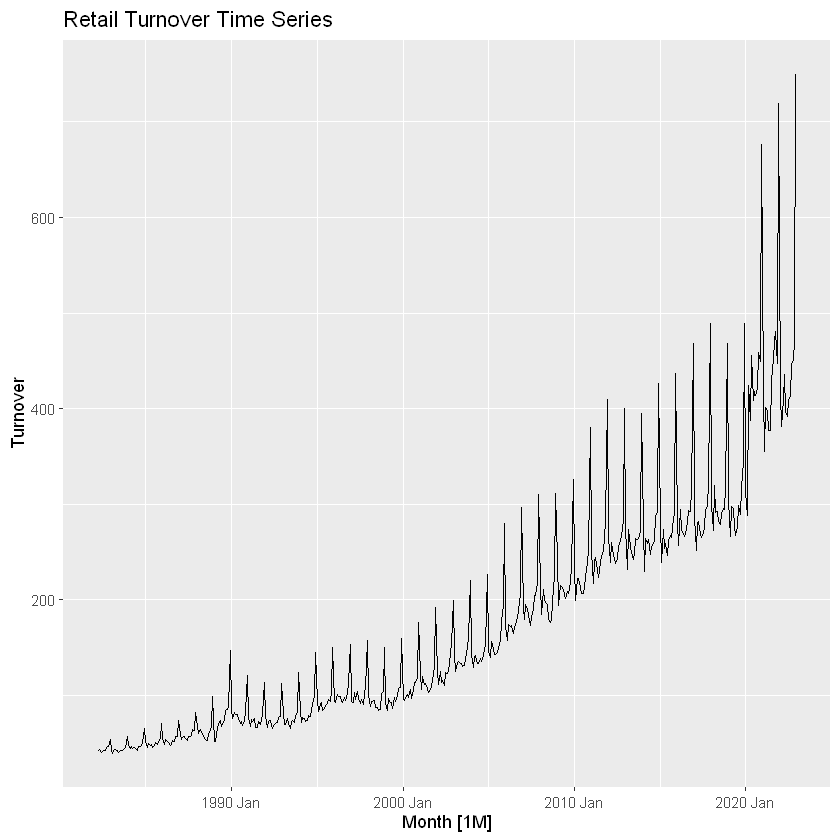

In [13]:
train <- retail |> filter_index(. ~ "2018 Dec")
test  <- retail |> filter_index("2019 Jan" ~ "2022 Dec")

autoplot(retail) + labs(title = "Retail Turnover Time Series")

1. What transformations (Box-Cox and/or differencing) would be required to make the data stationary? You should use a unit-root test as part of the discussion.

[1] -0.0344145

State,Industry,kpss_stat,kpss_pvalue
<chr>,<chr>,<dbl>,<dbl>
New South Wales,Liquor retailing,7.316487,0.01


ndiffs 
     1

nsdiffs 
      0

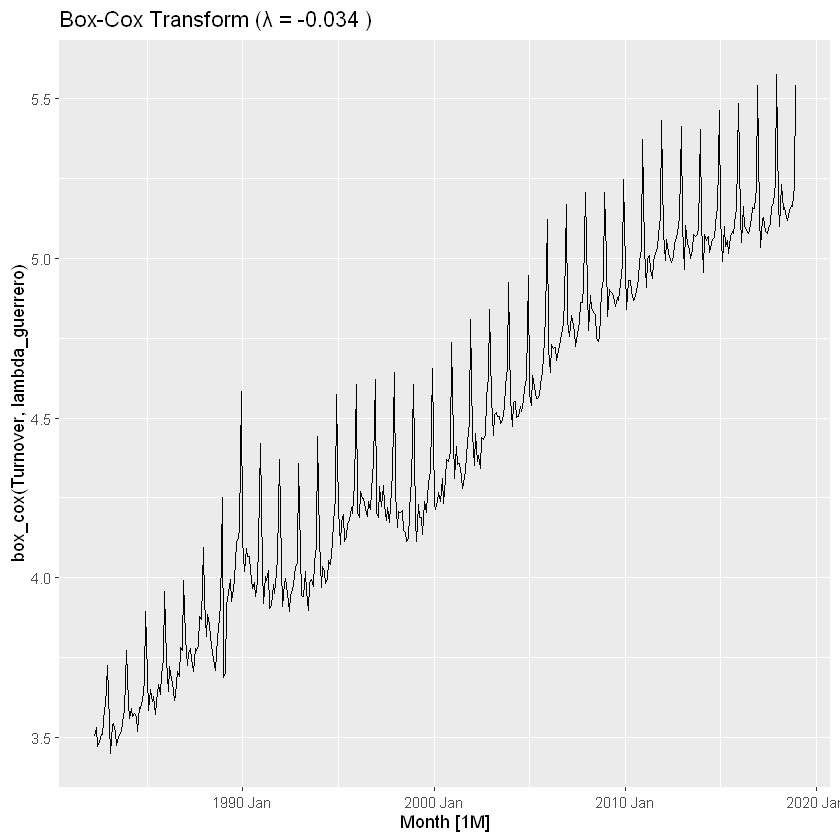

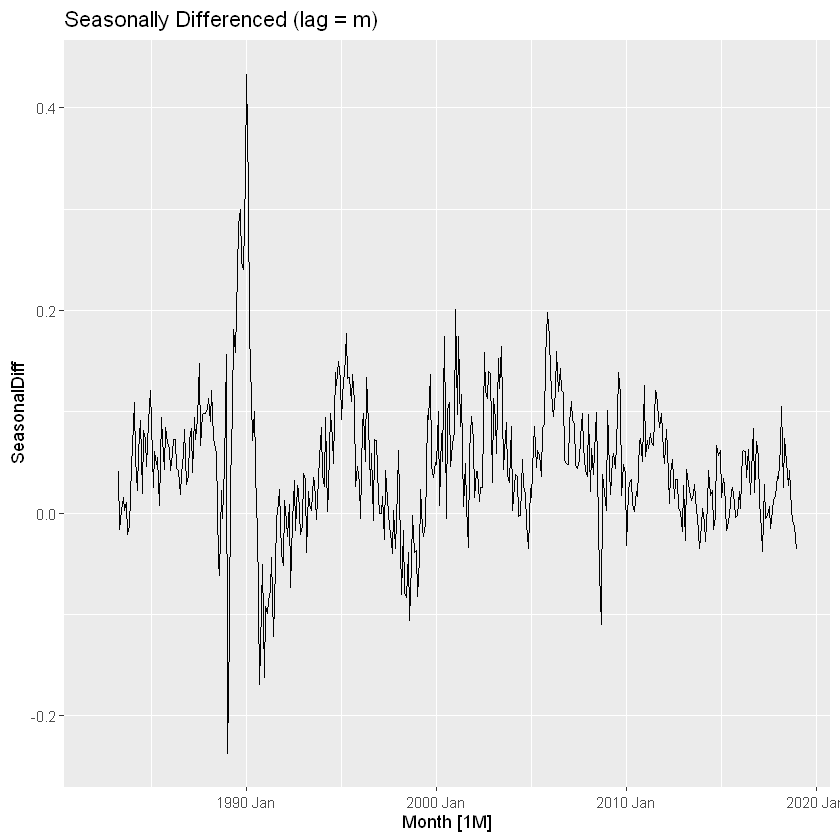

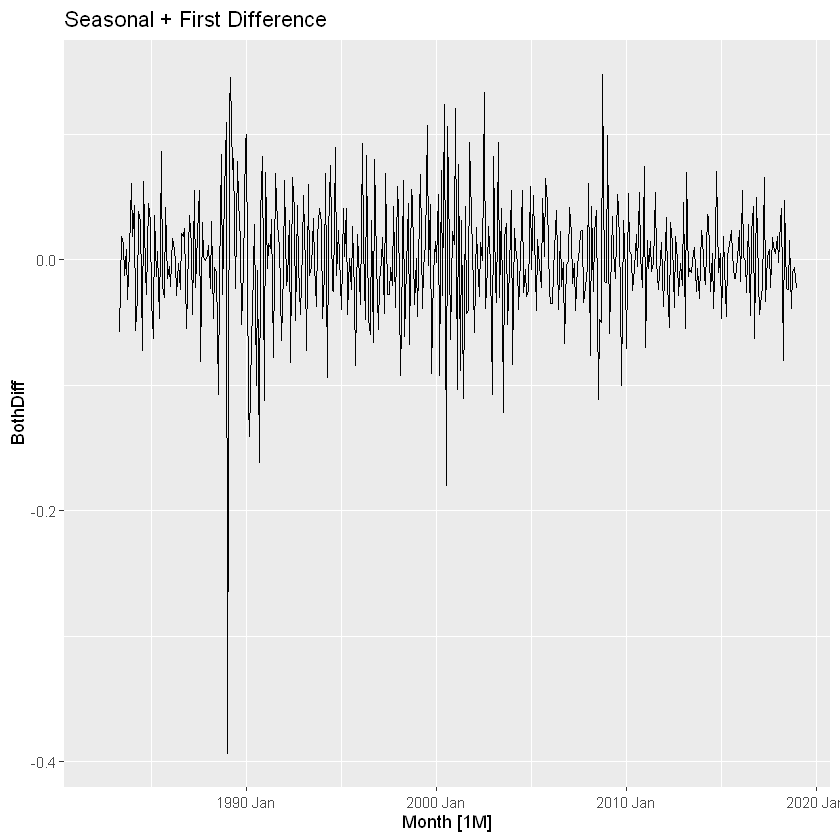

In [14]:
lambda_guerrero <- train |> features(Turnover, guerrero) |> pull(lambda_guerrero)
lambda_guerrero

train |> autoplot(box_cox(Turnover, lambda_guerrero)) +
labs(title = paste("Box-Cox Transform (λ =", round(lambda_guerrero, 3), ")"))

train_transformed <- train |>
mutate(Turn = box_cox(Turnover, lambda_guerrero))

train_transformed |> features(Turn, unitroot_kpss)

nd <- unitroot_ndiffs(train_transformed$Turn)
ns <- unitroot_nsdiffs(train_transformed$Turn)
nd; ns

m <- frequency(train)
autoplot(train_transformed |> mutate(SeasonalDiff = difference(Turn, lag = m)),
SeasonalDiff) +
labs(title = "Seasonally Differenced (lag = m)")

autoplot(train_transformed |> mutate(BothDiff = difference(difference(Turn, lag = m))),
BothDiff) +
labs(title = "Seasonal + First Difference")

Dėl laiko eilutėje stebimo heteroskedastiškumo pritaikyta Box-Cox transformacija ($\lambda \approx -0.034$), kuri stabilizavo dispersiją ir yra artima natūriniam logaritmui. Kadangi transformuota eilutė išliko nestacionari (KPSS testas $p < 0.05$), stacionarumui pasiekti atliktas dvigubas diferencijavimas: sezoninis ($D=1$) ir pirmos eilės ($d=1$). Gauta liekanų eilutė svyruoja aplink nulinį vidurkį ir vizualiai atitinka baltojo triukšmo savybes, nors 1990 m. duomenyse išlieka ryški specifinė išskirtis, galimai susijusi su vienkartiniais rinkos sukrėtimais.

2. Use a plot of the ACF and PACF of the (possibly differenced) data to determine two plausible ARIMA models for this data set.

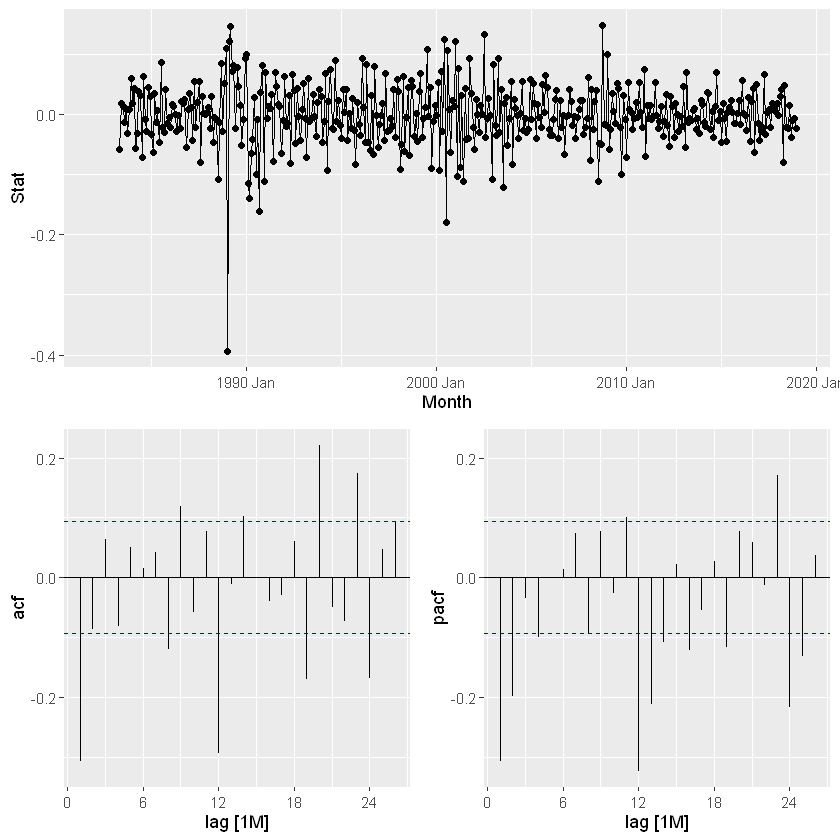

In [15]:
stationary <- train_transformed$Turn |>
difference(lag = m) |>
difference()

train |> mutate(Stat = stationary) |>
gg_tsdisplay(Stat, plot_type = "partial")

Analizuojant ACF grafiką, stebimi reikšmingi neigiami šuoliai ties pirmuoju ($lag=1$) ir dvyliktuoju ($lag=12$) vėlinimais, po kurių koreliacija staiga išnyksta, kas indikuoja $MA(1)$ ir sezoninį $MA(1)$ procesus ($ARIMA(0,1,1)(0,1,1)_{12}$). Alternatyviai, PACF grafikas ties tais pačiais vėlinimais taip pat rodo reikšmingas reikšmes, kas leidžia daryti prielaidą apie autoregresinius procesus ir pasirinkti antrąjį kandidatinį modelį $ARIMA(1,1,0)(1,1,0)_{12}$.

3. Fit both models, along with an automatically chosen model, and produce forecasts for 2019--2022.

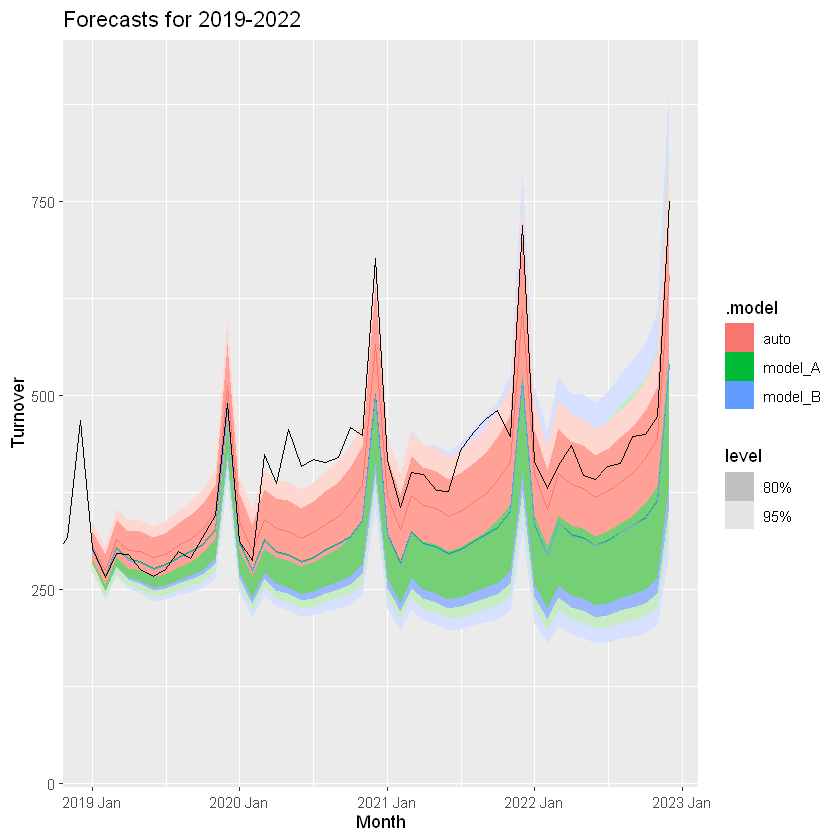

In [16]:
model_A_spec <- ARIMA(box_cox(Turnover, lambda_guerrero) ~ pdq(0,1,1) + PDQ(0,1,1))
model_B_spec <- ARIMA(box_cox(Turnover, lambda_guerrero) ~ pdq(2,1,0) + PDQ(0,1,1))

fit_models <- train |>
model(
model_A = model_A_spec,
model_B = model_B_spec,
auto    = ARIMA(box_cox(Turnover, lambda_guerrero))
)

model_metrics <- fit_models |> 
  glance() |> 
  arrange(AICc)
  
fc <- fit_models |> forecast(h = "4 years")

autoplot(fc, retail) +
  labs(title = "Forecasts for 2019-2022") +
  coord_cartesian(xlim = c(yearmonth("2019 Jan"), NA))

Vizualinė analizė rodo, kad tiek automatinis, tiek rankiniai modeliai generuoja beveik identiškas prognozes ir tiksliai atspindi sezoniškumą. Nors 2019 m. faktiniai duomenys patenka į prognozių pasikliautinuosius intervalus, nuo 2020 m. stebimas ryškus struktūrinis lūžis – reali apyvarta ženkliai viršija 95 proc. viršutinę ribą. Šį nuokrypį lemia COVID-19 pandemijos sukelti vartojimo pokyčiai, kurių modeliai, apmokyti su duomenimis iki 2018 m., negalėjo numatyti.

4. Which model is best based on AIC? Which model is best based on the test set RMSE? Which do you think is best to use for future forecasts? Why?

In [17]:
fit_models |> glance() |> arrange(AICc) |> select(.model, AICc)

accuracy_table <- fc |> accuracy(test)
accuracy_table |> select(.model, .type, RMSE, MAE, MAPE)

.model,AICc
<chr>,<dbl>
auto,-1533.789
model_A,-1506.566
model_B,-1504.251


.model,.type,RMSE,MAE,MAPE
<chr>,<chr>,<dbl>,<dbl>,<dbl>
auto,Test,57.25884,45.64414,10.46041
model_A,Test,99.72462,82.19000,18.37431
model_B,Test,100.66437,83.17531,18.60804


Remiantis informaciniu kriterijumi AICc, geriausias yra automatiškai parinktas modelis (auto), kurio reikšmė yra mažiausia (-1533,79). Vertinant prognostinį tikslumą testavimo imtyje, auto modelis taip pat demonstruoja geriausią rezultatą – jo RMSE (57,26) yra beveik dvigubai mažesnė nei rankiniu būdu sudarytų modelių (RMSE > 99). Ateities prognozėms pasirenkamas auto modelis, nes jis užtikrina tiek geriausią teorinį atitikimą duomenims (pagal AICc), tiek mažiausią prognozavimo paklaidą realioje situacijoje, tikėtina, dėl tiksliau parinktų diferencijavimo eilių ar konstantos įtraukimo.

5. Check the residuals from your preferred model, using an ACF plot and a Ljung-Box test. Do the residuals appear to be white noise?

.model,lb_stat,lb_pvalue
<chr>,<dbl>,<dbl>
auto,41.60028,0.0142997


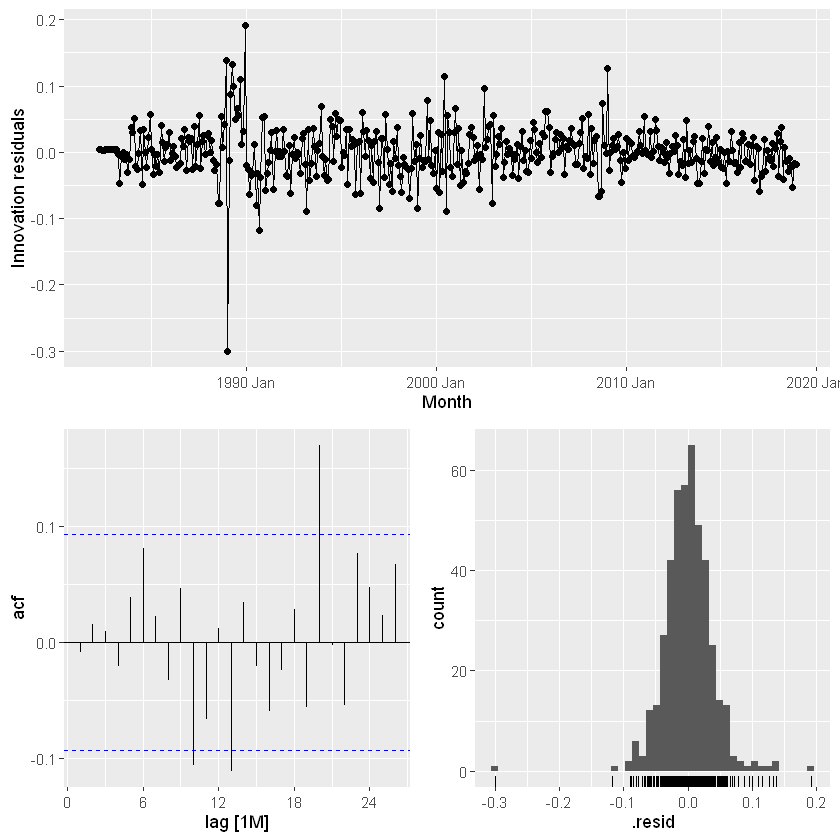

In [18]:
fit_models |> select(all_of("auto")) |> gg_tsresiduals()

fit_models |>
select(all_of("auto")) |>
augment() |>
features(.innov, ljung_box, lag = 24)

Vizualinė analizė rodo, kad modelis sėkmingai paaiškina pagrindinę duomenų dinamiką, tačiau formalus Ljung-Box testas ($p=0.0143 < 0.05$) atmeta prielaidą, kad liekanos yra visiškas baltasis triukšmas. Šį rezultatą ir liekanų skirstinio nuokrypį nuo normaliojo tikėtina lemia ne sisteminės modelio klaidos, o ryški 1990 m. fiksuota duomenų išskirtis, todėl modelis išlieka tinkamas prognozavimui.